In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


# Setup & Install Dependencies

In [3]:
!pip install open_clip_torch faiss-cpu scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 85.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.3

In [4]:
import os, json, random, time, math
from pathlib import Path
from typing import Optional, List, Tuple, Dict
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.cuda.amp import GradScaler
 
import numpy as np
from sklearn.metrics import roc_auc_score
import open_clip
from datasets import load_dataset
from tqdm import tqdm
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 
set_seed(42)
print(f"✅ All seeds set to {42}")

✅ All seeds set to 42


# DATA LOADING

In [7]:
print("📥 Loading Polyvore dataset from HuggingFace (owj0421/polyvore)...")
polyvore_ds = load_dataset('owj0421/polyvore')['data']
 
item_metadata = {}
item_id_to_idx = {}
 
for idx, example in enumerate(tqdm(polyvore_ds, desc="Indexing items")):
    item_id = str(example['item_id'])
    item_id_to_idx[item_id] = idx
    category = str(example.get('category', 'unknown'))
    item_metadata[item_id] = {'category_id': category}
 
print(f"✅ Loaded {len(item_metadata)} items.")

📥 Loading Polyvore dataset from HuggingFace (owj0421/polyvore)...


README.md: 0.00B [00:00, ?B/s]

data/data-00000-of-00005.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

data/data-00001-of-00005.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

data/data-00002-of-00005.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

...

data/data-00004-of-00005.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

data/data-00005-of-00005.parquet:   0%|          | 0.00/367M [00:00<?, ?B/s]

Generating data split: 0 examples [00:00, ? examples/s]

Indexing items: 100%|██████████| 251008/251008 [02:33<00:00, 1636.32it/s]

✅ Loaded 251008 items.


In [8]:
print("📥 Loading splits from owj0421/polyvore-outfits (disjoint_default)...")
outfits_by_split = {'train': [], 'valid': [], 'test': []}
 
splits_mapping = {'train': 'train', 'validation': 'valid', 'test': 'test'}
 
for hf_split, our_split in splits_mapping.items():
    outfit_ds = load_dataset('owj0421/polyvore-outfits', 'disjoint_default', split=hf_split)
    print(f"  Processing {hf_split} split ({len(outfit_ds)} outfits)...")
    for outfit in tqdm(outfit_ds, desc=f"  {hf_split}", leave=False):
        item_ids = [str(item['item_id']) for item in outfit['items']]
        if len(item_ids) >= 2 and all(iid in item_metadata for iid in item_ids):
            outfits_by_split[our_split].append(item_ids)
 
for split, outfits in outfits_by_split.items():
    print(f"  {split}: {len(outfits)} outfits")

📥 Loading splits from owj0421/polyvore-outfits (disjoint_default)...


README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

...

Generating test split:   0%|          | 0/15145 [00:00<?, ? examples/s]

  Processing train split (16995 outfits)...


  Processing validation split (3000 outfits)...


  Processing test split (15145 outfits)...


  train: 16995 outfits
  valid: 3000 outfits
  test: 15145 outfits


In [9]:
# First 5 items
first_5 = dict(list(item_metadata.items())[:5])

print(first_5)

{'211990161': {'category_id': 'tops'}, '183179503': {'category_id': 'bottoms'}, '152771755': {'category_id': 'jewellery'}, '190445143': {'category_id': 'bottoms'}, '211444470': {'category_id': 'bottoms'}}


In [10]:
from collections import defaultdict

category_to_items = defaultdict(list)

for item_id, meta in item_metadata.items():
    category_to_items[meta["category_id"]].append(item_id)

In [11]:
category_to_items["tops"][:5]

['211990161', '149817672', '182043322', '184924381', '117427809']

In [12]:
# Show first 5 categories and first 5 item IDs in each
for category, item_ids in list(category_to_items.items())[:5]:
    print(f"Category: {category}")
    print("First 5 item IDs:", item_ids[:5])
    print("-" * 40)

Category: tops
First 5 item IDs: ['211990161', '149817672', '182043322', '184924381', '117427809']
----------------------------------------
Category: bottoms
First 5 item IDs: ['183179503', '190445143', '211444470', '195532901', '193560014']
----------------------------------------
Category: jewellery
First 5 item IDs: ['152771755', '210309753', '166872904', '171008680', '126515743']
----------------------------------------
Category: shoes
First 5 item IDs: ['192704091', '203116108', '186722641', '171099609', '127357972']
----------------------------------------
Category: outerwear
First 5 item IDs: ['117334561', '127403908', '149509210', '164458368', '48308707']
----------------------------------------


In [13]:
from typing import List

def build_compat_lines(
    outfits: List[List[str]],
    item_metadata: dict,
    neg_ratio: int = 2,
    hard_negative_prob: float = 0.7,
    seed: int = 42,
):
    rng = random.Random(seed)

    all_ids = list(item_metadata.keys())
    all_ids_set = set(all_ids)

    # # Build category index once
    # category_to_items = {}
    # for item_id, meta in item_metadata.items():
    #     category = meta["category"]
    #     category_to_items.setdefault(category, []).append(item_id)

    lines = []

    for outfit in tqdm(outfits, desc="Building compatibility lines"):

        # Positive sample
        lines.append("1 " + " ".join(outfit))

        generated_negatives = set()

        while len(generated_negatives) < neg_ratio:

            corrupted = list(outfit)

            pos = rng.randrange(len(corrupted))

            original_item = corrupted[pos]
            original_category = item_metadata[original_item]["category_id"]

            corrupted_set = set(corrupted)

            # -----------------------------
            # Hard negative (same category)
            # -----------------------------
            if rng.random() < hard_negative_prob:

                candidates = [
                    i
                    for i in category_to_items[original_category]
                    if i not in corrupted_set
                ]

            # -----------------------------
            # Easy negative (random item)
            # -----------------------------
            else:

                candidates = list(all_ids_set - corrupted_set)

            if not candidates:
                continue

            corrupted[pos] = rng.choice(candidates)

            negative = tuple(corrupted)

            if negative in generated_negatives:
                continue

            generated_negatives.add(negative)

            lines.append("0 " + " ".join(corrupted))

    rng.shuffle(lines)

    return lines

In [14]:
compat_lines = {}

for split, outfits in outfits_by_split.items():

    compat_lines[split] = build_compat_lines(
        outfits,
        item_metadata,
        neg_ratio=2,
        hard_negative_prob=0.7,
    )

    pos = sum(line.startswith("1") for line in compat_lines[split])
    neg = sum(line.startswith("0") for line in compat_lines[split])

    print(
        f"{split}: {len(compat_lines[split])} "
        f"(pos={pos}, neg={neg})"
    )

Building compatibility lines: 100%|██████████| 16995/16995 [03:47<00:00, 74.78it/s]


train: 50985 (pos=16995, neg=33990)


Building compatibility lines: 100%|██████████| 3000/3000 [00:40<00:00, 73.77it/s]


valid: 9000 (pos=3000, neg=6000)


Building compatibility lines: 100%|██████████| 15145/15145 [03:40<00:00, 68.55it/s]


test: 45435 (pos=15145, neg=30290)


In [15]:
print("🔄 Loading OpenCLIP model for embedding extraction...")
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='laion2b_s34b_b79k'
)
clip_model = clip_model.to(device).eval()
print("✅ CLIP model loaded.")
 
print("🔄 Pre-extracting ALL embeddings to RAM (one-time cost)...")
print("   This will take a few minutes but makes training 100x faster.")
 
emb_dict: Dict[str, Tensor] = {}   # item_id → Tensor[512]  on CPU
EXTRACT_BATCH = 256
 
all_item_ids_list = list(item_id_to_idx.keys())
for start in tqdm(range(0, len(all_item_ids_list), EXTRACT_BATCH),
                  desc="Extracting embeddings"):
    batch_ids = all_item_ids_list[start: start + EXTRACT_BATCH]
    images = []
    valid_ids = []
    for iid in batch_ids:
        try:
            idx = item_id_to_idx[iid]
            img = polyvore_ds[idx]['image']
            if img is not None:
                images.append(preprocess(img))
                valid_ids.append(iid)
        except Exception:
            pass   # skip broken images silently
 
    if not images:
        continue
 
    img_batch = torch.stack(images).to(device)   # [B, 3, 224, 224]
    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast('cuda'):
                embs = clip_model.encode_image(img_batch)
        else:
            embs = clip_model.encode_image(img_batch)
        embs = embs.float().cpu()   # [B, 512] on CPU
 
    for iid, emb in zip(valid_ids, embs):
        emb_dict[iid] = emb   # L2-normalized later per-use, stored raw here

🔄 Loading OpenCLIP model for embedding extraction...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✅ CLIP model loaded.
🔄 Pre-extracting ALL embeddings to RAM (one-time cost)...
   This will take a few minutes but makes training 100x faster.


Extracting embeddings: 100%|██████████| 981/981 [16:26<00:00,  1.01s/it]


In [16]:
del clip_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
 
print(f"✅ Extracted {len(emb_dict)} / {len(all_item_ids_list)} embeddings.")
print(f"   RAM used: ~{len(emb_dict) * 512 * 4 / 1e6:.0f} MB")

✅ Extracted 251008 / 251008 embeddings.
   RAM used: ~514 MB


In [17]:
def get_emb(item_id: str) -> Tensor:
    """O(1) dict lookup — returns raw Tensor[512] on CPU."""
    emb = emb_dict.get(item_id)
    if emb is None:
        # Rare: item has no image. Return zero vector.
        return torch.zeros(512)
    return emb.float()

In [18]:
def generate_fitb_questions(test_outfits, item_metadata, num_questions=None, seed=42):
    rng = random.Random(seed)
    category_to_items = {}
    for iid, meta in item_metadata.items():
        cat = meta.get('category_id', 'unknown')
        category_to_items.setdefault(cat, []).append(iid)
 
    fitb_questions = []
    for outfit in tqdm(test_outfits, desc="Generating FITB questions"):
        if len(outfit) < 2:
            continue
        for pos_idx in range(len(outfit)):
            positive_id = outfit[pos_idx]
            question = outfit[:pos_idx] + outfit[pos_idx + 1:]
            if not question:
                continue
            category = item_metadata.get(positive_id, {}).get('category_id', 'unknown')
            candidates = [i for i in category_to_items.get(category, [])
                          if i != positive_id and i not in question
                          and i in emb_dict]   # only items we have embeddings for
            if len(candidates) < 3:
                all_items = [i for i in emb_dict if i != positive_id and i not in question]
                candidates = all_items
            if len(candidates) < 3:
                continue
            negatives = rng.sample(candidates, 3)
            answers = [positive_id] + negatives
            rng.shuffle(answers)
            fitb_questions.append({
                'question': question,
                'answers': answers,
                'blank_position': pos_idx
            })
    if num_questions is not None:
        fitb_questions = fitb_questions[:num_questions]
    return fitb_questions

In [19]:
fitb_questions = generate_fitb_questions(
    outfits_by_split['test'], item_metadata, num_questions=None, seed=42
)
print(f"✅ Generated {len(fitb_questions)} FITB questions")

Generating FITB questions: 100%|██████████| 15145/15145 [08:57<00:00, 28.19it/s]

✅ Generated 74262 FITB questions


#  Dataset Classes

## Helper


In [20]:
def _load_embedding(emb_dir: Path, item_id: str) -> Tensor:
    """
    Load a pre-computed image embedding from disk.

    Args:
        emb_dir:  Root directory containing <item_id>.pt files.
        item_id:  String identifier matching the filename stem.

    Returns:
        Tensor of shape [D] (float32).

    Raises:
        FileNotFoundError if the embedding file is missing.
    """
    path = emb_dir / f"{item_id}.pt"
    if not path.exists():
        raise FileNotFoundError(
            f"Embedding not found: {path}. "
            "Run the data generator from bigohofone/outfit-transformer first."
        )
    return torch.load(path, map_location="cpu").float()

In [21]:
def _collate_variable_length(batch):
    max_len = max(s["embeddings"].shape[0] for s in batch)
    dim = batch[0]["embeddings"].shape[1]
    emb_list, mask_list = [], []
    for s in batch:
        L = s["embeddings"].shape[0]
        pad = max_len - L
        emb_list.append(torch.cat([s["embeddings"], torch.zeros(pad, dim)], 0))
        mask_list.append(torch.cat([torch.ones(L, dtype=torch.bool),
                                     torch.zeros(pad, dtype=torch.bool)]))
    out = {
        "embeddings": torch.stack(emb_list),
        "mask":       torch.stack(mask_list),
    }
    for key in ("label", "positive", "negatives", "target_proto"):
        if key in batch[0]:
            if key == "negatives":
                max_negs = max(s[key].shape[0] for s in batch)
                neg_dim  = batch[0][key].shape[1]
                stacked  = []
                for s in batch:
                    k = s[key].shape[0]
                    stacked.append(torch.cat(
                        [s[key], torch.zeros(max_negs - k, neg_dim)], 0
                    ))
                out[key] = torch.stack(stacked)
            elif key == "label":
                out[key] = torch.tensor([s[key] for s in batch], dtype=torch.float32)
            else:
                out[key] = torch.stack([s[key] for s in batch])
    return out

## Compatibility Prediction Dataset

In [22]:
class CompatibilityDataset(Dataset):
    """
    Loads pre-built compat_lines (which already contain both label=1 and label=0).
    BUG 2 FIX: negatives are part of compat_lines, not generated on-the-fly
    here, so label assignment is deterministic and correct.
    """
    def __init__(self, split_lines: List[str], max_outfit_len: int = 16):
        super().__init__()
        self.max_outfit_len = max_outfit_len
        self.samples: List[Tuple[float, List[str]]] = []
        for line in split_lines:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            label = float(int(parts[0]))   # 0.0 or 1.0
            ids   = [i for i in parts[1:] if i in emb_dict]   # skip missing
            if len(ids) >= 2:
                self.samples.append((label, ids[:max_outfit_len]))
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        label, ids = self.samples[idx]
        embs = torch.stack([get_emb(i) for i in ids])   # [L, D]
        return {"embeddings": embs, "label": label}

## Complementary Item Retrieval Dataset

In [23]:
class ComplementaryItemDataset(Dataset):
    """
    CIR training dataset.
 
    BUG 4 FIX: uses pre-extracted emb_dict — O(1) lookup per item.
    Prototypes are pre-computed once at __init__ time, not on __getitem__.
    """
    def __init__(self, outfits: List[List[str]], item_metadata: Dict,
                 num_negatives: int = 10, hard_mining_stage: str = "coarse",
                 max_outfit_len: int = 16, min_outfit_len: int = 2):
        super().__init__()
        self.num_negatives      = num_negatives
        self.hard_mining_stage  = hard_mining_stage
 
        # Only keep outfits where all items have embeddings
        self.outfits = [
            [i for i in o if i in emb_dict][:max_outfit_len]
            for o in outfits
            if sum(1 for i in o if i in emb_dict) >= min_outfit_len
        ]
 
        # Category lookups
        self.item_to_coarse: Dict[str, str] = {}
        self.item_to_fine:   Dict[str, str] = {}
        self.coarse_to_items: Dict[str, List[str]] = {}
        self.fine_to_items:   Dict[str, List[str]] = {}
 
        for iid, meta in item_metadata.items():
            if iid not in emb_dict:
                continue   # skip items without embeddings
            coarse = str(meta.get('category_id', 'unknown'))
            fine   = str(meta.get('semantic_category', coarse))
            self.item_to_coarse[iid] = coarse
            self.item_to_fine[iid]   = fine
            self.coarse_to_items.setdefault(coarse, []).append(iid)
            self.fine_to_items.setdefault(fine, []).append(iid)
 
        # ── BUG 4 FIX: Pre-compute ALL category prototypes at init time ────
        # This way __getitem__ never triggers expensive computation.
        print(f"  Pre-computing {len(self.coarse_to_items)} category prototypes...")
        self._coarse_prototypes: Dict[str, Tensor] = {}
        for coarse, ids in self.coarse_to_items.items():
            embs = [get_emb(i) for i in ids]
            self._coarse_prototypes[coarse] = torch.stack(embs).mean(0)
        print(f"  ✅ Prototypes ready.")
 
    def set_hard_mining_stage(self, stage: str):
        assert stage in ("coarse", "fine")
        self.hard_mining_stage = stage
 
    def _sample_negatives(self, positive_id: str,
                          outfit_ids: List[str], k: int) -> List[str]:
        if self.hard_mining_stage == "fine":
            cat  = self.item_to_fine.get(positive_id, "")
            pool = self.fine_to_items.get(cat, [])
        else:
            cat  = self.item_to_coarse.get(positive_id, "")
            pool = self.coarse_to_items.get(cat, [])
 
        exclude    = set(outfit_ids) | {positive_id}
        candidates = [i for i in pool if i not in exclude]
        if len(candidates) < k:
            candidates = [i for ids in self.coarse_to_items.values()
                          for i in ids if i not in exclude]
        if not candidates:
            return [positive_id] * k
        chosen = random.sample(candidates, min(k, len(candidates)))
        while len(chosen) < k:
            chosen.append(random.choice(candidates))
        return chosen
 
    def __len__(self):
        return len(self.outfits)
 
    def __getitem__(self, idx):
        ids     = list(self.outfits[idx])
        pos_idx = random.randrange(len(ids))
        pos_id  = ids[pos_idx]
        partial = ids[:pos_idx] + ids[pos_idx + 1:]
 
        partial_embs = torch.stack([get_emb(i) for i in partial])  # [L-1, D]
        pos_emb      = get_emb(pos_id)                              # [D]
        coarse       = self.item_to_coarse.get(pos_id, "unknown")
        proto        = self._coarse_prototypes.get(
            coarse, torch.zeros(512)
        )                                                           # [D]
        neg_ids  = self._sample_negatives(pos_id, ids, self.num_negatives)
        neg_embs = torch.stack([get_emb(i) for i in neg_ids])      # [K, D]
 
        return {
            "embeddings":   partial_embs,
            "target_proto": proto,
            "positive":     pos_emb,
            "negatives":    neg_embs,
        }

## Fill-in-the-Blank Dataset (evaluation only)

In [24]:
class FITBDataset(Dataset):
    def __init__(self, fitb_questions: List[Dict], max_outfit_len: int = 16):
        self.questions     = fitb_questions
        self.max_outfit_len = max_outfit_len
 
    def __len__(self):
        return len(self.questions)
 
    def __getitem__(self, idx):
        q          = self.questions[idx]
        q_ids      = q["question"][:self.max_outfit_len]
        answer_ids = q["answers"]
        outfit_embs = torch.stack([get_emb(i) for i in q_ids])
        cand_embs   = torch.stack([get_emb(i) for i in answer_ids])
        return {"embeddings": outfit_embs, "candidates": cand_embs, "answer_idx": 0}
 

In [25]:
class CIRTestDataset(Dataset):
    """Deterministic test-time dataset for Recall@K evaluation."""
    def __init__(self, outfits: List[List[str]], item_metadata: Dict,
                 max_outfit_len: int = 16):
        self.item_to_coarse: Dict[str, str] = {}
        self.coarse_to_items: Dict[str, List[str]] = {}
        for iid, meta in item_metadata.items():
            if iid not in emb_dict:
                continue
            coarse = str(meta.get('category_id', 'unknown'))
            self.item_to_coarse[iid] = coarse
            self.coarse_to_items.setdefault(coarse, []).append(iid)
 
        # Pre-compute prototypes (same as ComplementaryItemDataset)
        self._prototypes: Dict[str, Tensor] = {}
        for coarse, ids in self.coarse_to_items.items():
            self._prototypes[coarse] = torch.stack([get_emb(i) for i in ids]).mean(0)
 
        self.samples: List[Tuple[List[str], int]] = []
        for o in outfits:
            ids = [i for i in o if i in emb_dict][:max_outfit_len]
            if len(ids) >= 2:
                for pos_idx in range(len(ids)):
                    self.samples.append((ids, pos_idx))
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        ids, pos_idx = self.samples[idx]
        pos_id       = ids[pos_idx]
        partial      = ids[:pos_idx] + ids[pos_idx + 1:]
        partial_embs = torch.stack([get_emb(i) for i in partial])
        coarse       = self.item_to_coarse.get(pos_id, "unknown")
        proto        = self._prototypes.get(coarse, torch.zeros(512))
        return {"embeddings": partial_embs, "target_proto": proto,
                "gt_item_id": pos_id}

## Retrieval Index Dataset (for building the KNN index at eval time)

In [26]:
class ItemEmbeddingDataset(Dataset):
    """
    Flat dataset of all item embeddings in the database.
    Used during evaluation to build a FAISS or HNSWlib KNN index.

    Args:
        item_ids:  Ordered list of item IDs to index.
        emb_dir:   Directory containing <item_id>.pt files.
    """

    def __init__(self, item_ids, emb_cache):
        self.item_ids = item_ids
        self.emb_cache = emb_cache

    def __len__(self):
        return len(self.item_ids)

    def __getitem__(self, idx):
        iid = self.item_ids[idx]
        emb = self.emb_cache.get_emb(iid)
        return iid, emb

## Factory / convenience helpers

In [27]:
def cir_test_collate(batch):
    max_len = max(s["embeddings"].shape[0] for s in batch)
    dim     = batch[0]["embeddings"].shape[1]
    emb_list, mask_list = [], []
    for s in batch:
        L = s["embeddings"].shape[0]; pad = max_len - L
        emb_list.append(torch.cat([s["embeddings"], torch.zeros(pad, dim)], 0))
        mask_list.append(torch.cat([torch.ones(L, dtype=torch.bool),
                                     torch.zeros(pad, dtype=torch.bool)]))
    return {
        "embeddings":   torch.stack(emb_list),
        "mask":         torch.stack(mask_list),
        "target_proto": torch.stack([s["target_proto"] for s in batch]),
        "gt_item_id":   [s["gt_item_id"] for s in batch],
    }

In [28]:
def fitb_collate(batch):
    max_len = max(s["embeddings"].shape[0] for s in batch)
    dim     = batch[0]["embeddings"].shape[1]
    emb_list, mask_list = [], []
    for s in batch:
        L = s["embeddings"].shape[0]; pad = max_len - L
        emb_list.append(torch.cat([s["embeddings"], torch.zeros(pad, dim)], 0))
        mask_list.append(torch.cat([torch.ones(L, dtype=torch.bool),
                                     torch.zeros(pad, dtype=torch.bool)]))
    return {
        "embeddings": torch.stack(emb_list),
        "mask":       torch.stack(mask_list),
        "candidates": torch.stack([s["candidates"] for s in batch]),
        "answer_idx": torch.tensor([s["answer_idx"] for s in batch]),
    }
 

In [29]:
def build_cp_datasets(
    data_root: str,
    emb_dir: str,
    splits: Tuple[str, ...] = ("train", "valid", "test"),
) -> Dict[str, CompatibilityDataset]:
    """
    Convenience function that builds CompatibilityDataset for each split.

    Args:
        data_root: Path to polyvore_outfits/.
        emb_dir:   Path to pre-computed embedding directory.
        splits:    Which splits to load.

    Returns:
        Dict mapping split name to CompatibilityDataset.
    """
    root = Path(data_root)
    datasets = {}
    for split in splits:
        split_file = root / f"compatibility_{split}.txt"
        if not split_file.exists():
            print(f"[WARN] {split_file} not found – skipping.")
            continue
        datasets[split] = CompatibilityDataset(
            data_root=str(root),
            split_file=str(split_file),
            emb_dir=emb_dir,
        )
    return datasets


In [30]:
def build_cir_datasets(
    data_root: str,
    emb_dir: str,
    splits: Tuple[str, ...] = ("train", "valid", "test"),
) -> Dict[str, ComplementaryItemDataset]:
    """
    Convenience function that builds ComplementaryItemDataset for each split.
    """
    root = Path(data_root)
    meta_file = root / "polyvore_item_metadata.json"
    datasets = {}
    for split in splits:
        split_file = root / f"{split}.json"
        if not split_file.exists():
            print(f"[WARN] {split_file} not found – skipping.")
            continue
        datasets[split] = ComplementaryItemDataset(
            data_root=str(root),
            split_file=str(split_file),
            emb_dir=emb_dir,
            item_metadata=str(meta_file),
        )
    return datasets

# Model Definition

## Sub-modules

In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-8):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(dim))
        self.eps   = eps
    def forward(self, x: Tensor) -> Tensor:
        return self.scale * x / x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()

In [ ]:
class MLPMixerBlock(nn.Module):
    def __init__(self, d_in: int, d_hidden: Optional[int] = None, dropout: float = 0.0):
        super().__init__()
        d_hidden = d_hidden or 4 * d_in
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_hidden, d_in), nn.Dropout(dropout),
        )
    def forward(self, x: Tensor) -> Tensor:
        return x + self.net(x)

In [ ]:
class GatedResidualAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int,
                 d_ff: Optional[int] = None, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model; self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.ln_attn = RMSNorm(d_model)
        self.q_proj  = nn.Linear(d_model, d_model)
        self.k_proj  = nn.Linear(d_model, d_model)
        self.v_proj  = nn.Linear(d_model, d_model)
        self.out_proj= nn.Linear(d_model, d_model)
        self.gate_proj = nn.Linear(d_model, d_model)
        self.attn_bias = nn.Parameter(torch.zeros(1, n_heads, 1, 1))
        self.attn_drop = nn.Dropout(dropout)
        d_ff = d_ff or 4 * d_model
        self.ln_ff  = RMSNorm(d_model)
        self.ff_net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
 
    def forward(self, x: Tensor,
                key_padding_mask: Optional[Tensor] = None) -> Tensor:
        B, L, D = x.shape
        gate = torch.sigmoid(self.gate_proj(x))
        xn   = self.ln_attn(x)
        def sh(t): return t.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        Q, K, V = sh(self.q_proj(xn)), sh(self.k_proj(xn)), sh(self.v_proj(xn))
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        scores  = scores + self.attn_bias
        if key_padding_mask is not None:
            scores = scores.masked_fill(
                (~key_padding_mask).unsqueeze(1).unsqueeze(2), float("-inf"))
        aw  = self.attn_drop(F.softmax(scores, dim=-1))
        out = torch.matmul(aw, V).transpose(1, 2).contiguous().view(B, L, D)
        x   = x + gate * self.out_proj(out)
        x   = x + self.ff_net(self.ln_ff(x))
        return x


In [ ]:
class PerceiverLatentPool(nn.Module):
    def __init__(self, d_model: int, n_slots: int = 4,
                 n_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_slots = n_slots; self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.slots   = nn.Parameter(torch.randn(1, n_slots, d_model) * 0.02)
        self.ln_q    = RMSNorm(d_model); self.ln_kv  = RMSNorm(d_model)
        self.q_proj  = nn.Linear(d_model, d_model)
        self.k_proj  = nn.Linear(d_model, d_model)
        self.v_proj  = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.drop    = nn.Dropout(dropout)
        self.slot_attn = nn.Linear(d_model, 1)
 
    def forward(self, x: Tensor,
                key_padding_mask: Optional[Tensor] = None) -> Tensor:
        B, L, D = x.shape; S = self.n_slots
        Q_raw = self.slots.expand(B, -1, -1)
        def sh(t, s): return t.view(B, s, self.n_heads, self.d_head).transpose(1, 2)
        Q = sh(self.q_proj(self.ln_q(Q_raw)), S)
        K = sh(self.k_proj(self.ln_kv(x)), L)
        V = sh(self.v_proj(x), L)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        if key_padding_mask is not None:
            scores = scores.masked_fill(
                (~key_padding_mask).unsqueeze(1).unsqueeze(2), float("-inf"))
        sv = self.drop(F.softmax(scores, dim=-1))
        sv = torch.matmul(sv, V).transpose(1, 2).contiguous().view(B, S, D)
        sv = self.out_proj(sv) + Q_raw
        w  = F.softmax(self.slot_attn(sv), dim=1)
        return (w * sv).sum(1)

In [ ]:
class VisualPrototypeCrossAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads; self.d_head = d_model // n_heads
        self.ln_q = RMSNorm(d_model); self.ln_kv = RMSNorm(d_model)
        self.q_proj  = nn.Linear(d_model, d_model)
        self.k_proj  = nn.Linear(d_model, d_model)
        self.v_proj  = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.drop    = nn.Dropout(dropout)
        self.ln_ff   = RMSNorm(d_model)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, 4 * d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(4 * d_model, d_model),
        )
 
    def forward(self, proto: Tensor, context: Tensor,
                context_mask: Optional[Tensor] = None) -> Tensor:
        B, L, D = context.shape
        def sh(t, s): return t.view(B, s, self.n_heads, self.d_head).transpose(1, 2)
        q = proto.unsqueeze(1)
        Q = sh(self.q_proj(self.ln_q(q)), 1)
        K = sh(self.k_proj(self.ln_kv(context)), L)
        V = sh(self.v_proj(context), L)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        if context_mask is not None:
            scores = scores.masked_fill(
                (~context_mask).unsqueeze(1).unsqueeze(2), float("-inf"))
        out = torch.matmul(self.drop(F.softmax(scores, dim=-1)), V)
        out = self.out_proj(out.transpose(1, 2).contiguous().view(B, 1, D)).squeeze(1)
        out = out + proto
        out = out + self.ff(self.ln_ff(out))
        return out

## Main Model

In [ ]:
class VisualOutfitTransformer(nn.Module):
    def __init__(self, d_in: int = 512, d_model: int = 256, n_layers: int = 6,
                 n_heads: int = 8, n_slots: int = 4, d_out: int = 256,
                 dropout: float = 0.1):
        super().__init__()
        self.d_in = d_in; self.d_model = d_model; self.d_out = d_out
        self.item_proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), RMSNorm(d_model),
        )
        self.transformer = nn.ModuleList([
            GatedResidualAttention(d_model, n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.perceiver_pool = PerceiverLatentPool(
            d_model, n_slots, min(n_heads, 4), dropout)
        # ── BUG 2 FIX: Keep nn.Sigmoid() in cp_head ──────────────────────
        # Without Sigmoid, the output is a raw logit and FocalBCELoss must
        # use binary_cross_entropy_with_logits. Mixing the two (sigmoid output
        # with logit loss) causes numerical instability and loss collapse.
        # We keep Sigmoid here and use F.binary_cross_entropy in FocalBCELoss.
        self.cp_head = nn.Sequential(
            MLPMixerBlock(d_model, d_model * 2, dropout),
            RMSNorm(d_model),
            nn.Linear(d_model, 1),
            # nn.Sigmoid(),          # ← KEEP THIS. Removed in your notebook = Bug 2
        )
        self.proto_proj = nn.Sequential(nn.Linear(d_in, d_model), RMSNorm(d_model))
        self.proto_cross_attn = VisualPrototypeCrossAttention(
            d_model, min(n_heads, 4), dropout)
        self.cir_head = nn.Sequential(
            MLPMixerBlock(d_model, d_model * 2, dropout),
            RMSNorm(d_model), nn.Linear(d_model, d_out),
        )
        self.item_encoder = nn.Sequential(
            nn.Linear(d_in, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model, d_out),
        )
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
 
    def _encode_items(self, embeddings: Tensor,
                      mask: Optional[Tensor] = None) -> Tuple[Tensor, Optional[Tensor]]:
        x = self.item_proj(embeddings)
        for layer in self.transformer:
            x = layer(x, key_padding_mask=mask)
        return x, mask
 
    def forward_cp(self, embeddings: Tensor,
                   mask: Optional[Tensor] = None) -> Tensor:
        tokens, mask = self._encode_items(embeddings, mask)
        outfit_repr  = self.perceiver_pool(tokens, mask)
        return self.cp_head(outfit_repr).squeeze(-1)   # [B], already in (0,1)
 
    def forward_cir(self, embeddings: Tensor, target_proto: Tensor,
                    mask: Optional[Tensor] = None) -> Tensor:
        tokens, mask  = self._encode_items(embeddings, mask)
        proto_d       = self.proto_proj(target_proto)
        refined_proto = self.proto_cross_attn(proto_d, tokens, mask)
        return F.normalize(self.cir_head(refined_proto), p=2, dim=-1)
 
    def encode_item(self, item_emb: Tensor) -> Tensor:
        return F.normalize(self.item_encoder(item_emb), p=2, dim=-1)
 
    def forward(self, embeddings, mask=None, target_proto=None, task="cp"):
        if task == "cp":  return self.forward_cp(embeddings, mask)
        if task == "cir": return self.forward_cir(embeddings, target_proto, mask)
        raise ValueError(f"Unknown task: {task}")

## Loss functions

In [ ]:
class FocalBCELoss(nn.Module):
    def __init__(self, gamma: float = 2.0, alpha: float = 0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits: Tensor, target: Tensor) -> Tensor:
        # Apply sigmoid HERE, outside of autocast, where float32 is guaranteed.
        # binary_cross_entropy_with_logits is AMP-safe and numerically stable.
        bce = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
        # For focal weighting we still need the probability
        probs = torch.sigmoid(logits)
        pt    = torch.where(target == 1.0, probs, 1.0 - probs)
        fw    = (1.0 - pt) ** self.gamma
        aw    = torch.where(
            target == 1.0,
            torch.full_like(target, self.alpha),
            torch.full_like(target, 1.0 - self.alpha),
        )
        return (aw * fw * bce).mean()

In [ ]:
class SetWiseOutfitRankingLoss(nn.Module):
    def __init__(self, margin: float = 0.2):
        super().__init__(); self.margin = margin
 
    def _l2(self, a: Tensor, b: Tensor) -> Tensor:
        return (a - b).pow(2).sum(-1).clamp(min=0).sqrt()
 
    def forward(self, query: Tensor, positive: Tensor, negatives: Tensor) -> Tensor:
        d_pos = self._l2(query, positive)                            # [B]
        B, K, D = negatives.shape
        qe  = query.unsqueeze(1).expand_as(negatives)
        dn  = self._l2(qe.reshape(B*K,D), negatives.reshape(B*K,D)).view(B,K)
        L_all  = F.relu(d_pos.unsqueeze(1).expand(B,K) - dn + self.margin).mean()
        L_hard = F.relu(d_pos - dn.min(1).values + self.margin).mean()
        return L_all + L_hard

##  Quick check

In [ ]:
torch.manual_seed(0)

B, L, D_in = 4, 6, 512

model = VisualOutfitTransformer(
    d_in=D_in, d_model=128, n_layers=3, n_heads=4, n_slots=4, d_out=128
)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

embs  = torch.randn(B, L, D_in)
mask  = torch.ones(B, L, dtype=torch.bool)
mask[0, -2:] = False   # simulate 2 padding tokens in batch[0]
proto = torch.randn(B, D_in)

# CP forward
score = model.forward_cp(embs, mask)
print(f"CP score shape: {score.shape}  values: {score}")

# CIR forward
query = model.forward_cir(embs, proto, mask)
print(f"CIR query shape: {query.shape}  norm: {query.norm(dim=-1)}")

# Item encoding
single = model.encode_item(torch.randn(B, D_in))
print(f"Item encoding shape: {single.shape}  norm: {single.norm(dim=-1)}")

# Loss check
cp_loss_fn  = FocalBCELoss()
cir_loss_fn = SetWiseOutfitRankingLoss(margin=0.2)

cp_loss = cp_loss_fn(score, torch.randint(0, 2, (B,)).float())
print(f"Focal CP loss: {cp_loss.item():.4f}")

pos_emb = model.encode_item(torch.randn(B, D_in))
neg_emb = model.encode_item(torch.randn(B, 8, D_in).reshape(B * 8, D_in)).view(B, 8, -1)
cir_loss = cir_loss_fn(query, pos_emb, neg_emb)
print(f"Set-wise CIR loss: {cir_loss.item():.4f}")

Model parameters: 1,369,742
CP score shape: torch.Size([4])  values: tensor([-0.3062,  1.1573,  0.9591, -0.1271], grad_fn=<SqueezeBackward1>)
CIR query shape: torch.Size([4, 128])  norm: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<LinalgVectorNormBackward0>)
Item encoding shape: torch.Size([4, 128])  norm: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<LinalgVectorNormBackward0>)
Focal CP loss: 0.0345
Set-wise CIR loss: 0.4250


# Training Functions

## Helpers

In [ ]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
def warmup_cosine_schedule(optimizer, warmup_steps, total_steps, min_lr=0.01):
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / max(1, warmup_steps)
        p = float(step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(min_lr, 0.5 * (1.0 + math.cos(math.pi * p)))
    return LambdaLR(optimizer, lr_lambda)

In [ ]:
def save_checkpoint(model, optimizer, scheduler, scaler, epoch, phase, metrics, out_dir):
    ckpt = {"epoch": epoch, "phase": phase, "model": model.state_dict(),
            "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(),
            "metrics": metrics}
    if scaler is not None:
        ckpt["scaler"] = scaler.state_dict()
    path = out_dir / f"{phase}_epoch{epoch:03d}.pt"
    torch.save(ckpt, path)
    print(f"  [ckpt] Saved → {path}")
    return path

In [ ]:
def load_checkpoint(model: nn.Module, path: str, device: torch.device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"])
    print(f"  [ckpt] Loaded weights from {path} (epoch {ckpt['epoch']})")
    return ckpt

## Phase 1: CP Pre-training

In [ ]:
def train_cp_epoch(model, loader, optimizer, scheduler, scaler,
                   loss_fn, device, accum_steps, epoch):
    model.train(); optimizer.zero_grad(set_to_none=True)
    total_loss = 0.0; n_batches = 0; accum_count = 0
    pbar = tqdm(loader, desc=f"CP Epoch {epoch}", leave=False)
    for batch in pbar:
        embs   = batch["embeddings"].to(device)
        mask   = batch["mask"].to(device)
        labels = batch["label"].to(device)
 
        if device.type == "cuda" and scaler is not None:
            with torch.amp.autocast('cuda'):
                scores = model.forward_cp(embs, mask)
                loss   = loss_fn(scores, labels) / accum_steps
            scaler.scale(loss).backward()
        else:
            scores = model.forward_cp(embs, mask)
            loss   = loss_fn(scores, labels) / accum_steps
            loss.backward()
 
        accum_count += 1
        if accum_count == accum_steps:
            if scaler is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step(); optimizer.zero_grad(set_to_none=True); accum_count = 0
 
        total_loss += loss.item() * accum_steps; n_batches += 1
        pbar.set_postfix({"loss": f"{total_loss/n_batches:.4f}"})
 
    if accum_count > 0:
        if scaler is not None:
            scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        optimizer.zero_grad(set_to_none=True)
    return total_loss / max(n_batches, 1)

In [ ]:
def validate_cp(model, loader, loss_fn, device):
    model.eval()
    all_scores, all_labels = [], []
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validating CP", leave=False):
            embs   = batch["embeddings"].to(device)
            mask   = batch["mask"].to(device)
            labels = batch["label"].to(device)
            logits = model.forward_cp(embs, mask)          # raw logits
            loss   = loss_fn(logits, labels)
            probs  = torch.sigmoid(logits)                 # ← convert for AUC
            all_scores.extend(probs.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            total_loss += loss.item(); n += 1

    unique = set(all_labels)
    auc = roc_auc_score(all_labels, all_scores) if len(unique) >= 2 else 0.5
    return {"val_loss": total_loss / max(n, 1), "auc": float(auc)}

## Phase 2: CIR Fine-tuning

In [113]:
def train_cir_epoch(model, loader, optimizer, scheduler, scaler,
                    loss_fn, device, accum_steps, epoch):
    model.train(); optimizer.zero_grad(set_to_none=True)
    total_loss = 0.0; n_batches = 0; accum_count = 0
    pbar = tqdm(loader, desc=f"CIR Epoch {epoch}", leave=False)
 
    for step, batch in enumerate(pbar):
        embs  = batch["embeddings"].to(device)
        mask  = batch["mask"].to(device)
        proto = batch["target_proto"].to(device)
        pos   = batch["positive"].to(device)
        negs  = batch["negatives"].to(device)
 
        # ── BUG 3 FIX: guard ALL scaler calls with `if scaler is not None` ──
        # Your original train_cir_epoch called scaler.scale(loss).backward()
        # unconditionally. On CPU scaler=None → AttributeError → tqdm
        # silently swallowed it → appeared as a permanent hang at 0%.
        if device.type == "cuda" and scaler is not None:
            with torch.amp.autocast('cuda'):
                query   = model.forward_cir(embs, proto, mask)
                pos_enc = model.encode_item(pos)
                B, K, D = negs.shape
                neg_enc = model.encode_item(negs.view(B*K,D)).view(B,K,-1)
                loss    = loss_fn(query, pos_enc, neg_enc) / accum_steps
            scaler.scale(loss).backward()
        else:
            query   = model.forward_cir(embs, proto, mask)
            pos_enc = model.encode_item(pos)
            B, K, D = negs.shape
            neg_enc = model.encode_item(negs.view(B*K,D)).view(B,K,-1)
            loss    = loss_fn(query, pos_enc, neg_enc) / accum_steps
            loss.backward()
 
        accum_count += 1
        if accum_count == accum_steps:
            if scaler is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step(); optimizer.zero_grad(set_to_none=True); accum_count = 0
 
        total_loss += loss.item() * accum_steps; n_batches += 1
        pbar.set_postfix({"loss": f"{total_loss/n_batches:.4f}"})
 
    if accum_count > 0:
        if scaler is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
    
        scheduler.step()                     # <-- add this
        optimizer.zero_grad(set_to_none=True)
    return total_loss / max(n_batches, 1)

## Main

In [114]:
def run_training(config):
    """
    Run the full two-phase training (CP -> CIR) using in-memory data.
    
    Required config keys:
      - outfits_by_split: dict with 'train', 'valid', 'test' -> list of outfit item ID lists
      - item_metadata: dict mapping item_id -> {'category_id': ...}
      - emb_cache: EmbeddingCache instance
      - compat_lines: dict with 'train', 'valid', 'test' -> list of "1 item_id ..." strings
    
    Optional:
      - resume_cp: path to CP checkpoint to resume from
      - resume_cir: path to CIR checkpoint to resume from (skips CP)
      - skip_cp: bool, if True skip CP pre-training
    """
    # Reproducibility
    set_seed(config["seed"])

    output_dir = Path(config["output_dir"])
    output_dir.mkdir(parents=True, exist_ok=True)

    # Save config (remove non-serializable objects)
    serializable_config = {k: v for k, v in config.items() 
                           if not isinstance(v, (EmbeddingCache, dict, list))}
    with open(output_dir / "config.json", "w") as f:
        json.dump(serializable_config, f, indent=2)

    # Build model
    model = VisualOutfitTransformer(
        d_in=config["d_in"], d_model=config["d_model"],
        n_layers=config["n_layers"], n_heads=config["n_heads"],
        n_slots=config["n_slots"], d_out=config["d_out"],
        dropout=config["dropout"]
    ).to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    cp_loss_fn = FocalBCELoss(gamma=2.0, alpha=0.25)
    cir_loss_fn = SetWiseOutfitRankingLoss(margin=config["margin"])
    scaler = torch.amp.GradScaler('cuda') if device.type == "cuda" else None

    # Unpack data objects from config
    outfits_by_split = config["outfits_by_split"]
    item_metadata = config["item_metadata"]
    emb_cache = config["emb_cache"]
    compat_lines = config["compat_lines"]

    # If test_mode is enabled, use only a small fraction
    if config.get("test_mode", False):
        print("🧪 TEST MODE: Using small subset of data for sanity check.")
        # Reduce dataset sizes
        for split in ['train', 'valid']:
            # Keep only first 10 outfits
            config["outfits_by_split"][split] = config["outfits_by_split"][split][:10]
            config["compat_lines"][split] = config["compat_lines"][split][:10]
        # Reduce epochs
        config["cp_epochs"] = min(config["cp_epochs"], 2)
        config["cir_epochs"] = min(config["cir_epochs"], 2)

    # ── Phase 1: CP Pre‑training ──────────────────────────────
    if not config.get("skip_cp", False) and config.get("resume_cir") is None:
        print("\n" + "="*60)
        print("PHASE 1: Compatibility Prediction Pre-training")
        print("="*60)

        cp_train = CompatibilityDataset(compat_lines['train'], item_metadata, emb_cache, neg_ratio=1)
        cp_valid = CompatibilityDataset(compat_lines['valid'], item_metadata, emb_cache, neg_ratio=1)

        cp_train_loader = DataLoader(
            cp_train, batch_size=config["batch_size"], shuffle=True,
            num_workers=config["num_workers"], collate_fn=_collate_variable_length,
            pin_memory=(device.type=="cuda"), drop_last=True
        )
        cp_valid_loader = DataLoader(
            cp_valid, batch_size=config["batch_size"]*2, shuffle=False,
            num_workers=config["num_workers"], collate_fn=_collate_variable_length,
            pin_memory=(device.type=="cuda")
        )

        total_cp_steps = len(cp_train_loader)//config["accum_steps"] * config["cp_epochs"]
        warmup_steps = int(total_cp_steps * config["warmup_ratio"])

        cp_optimizer = AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
        cp_scheduler = get_cosine_schedule_with_warmup(optimizer=cp_optimizer,num_warmup_steps=warmup_steps,num_training_steps=total_cp_steps,)
        start_epoch = 1
        if config.get("resume_cp"):
            ckpt = load_checkpoint(model, config["resume_cp"], device)
            cp_optimizer.load_state_dict(ckpt["optimizer"])
            cp_scheduler.load_state_dict(ckpt["scheduler"])
            scaler.load_state_dict(ckpt["scaler"])
            start_epoch = ckpt["epoch"] + 1

        best_auc = 0.0
        best_cp_path = None

        for epoch in range(start_epoch, config["cp_epochs"]+1):
            t0 = time.time()
            train_loss = train_cp_epoch(
                model, cp_train_loader, cp_optimizer, cp_scheduler,
                scaler, cp_loss_fn, device, config["accum_steps"], epoch
            )
            val_metrics = validate_cp(model, cp_valid_loader, cp_loss_fn, device)
            print(f"[CP] Epoch {epoch}/{config['cp_epochs']} | "
                  f"train_loss={train_loss:.4f} | val_loss={val_metrics['val_loss']:.4f} | "
                  f"AUC={val_metrics['auc']:.4f} | time={time.time()-t0:.0f}s")

            save_checkpoint(model, cp_optimizer, cp_scheduler, scaler,
                            epoch, "cp", val_metrics, output_dir)
            if val_metrics["auc"] > best_auc:
                best_auc = val_metrics["auc"]
                best_cp_path = output_dir / "cp_best.pt"
                torch.save(model.state_dict(), best_cp_path)
                print(f"  [best] New best CP AUC={best_auc:.4f}")

        print(f"\nCP pre-training complete. Best AUC: {best_auc:.4f}")

    # Load best CP weights if available and not resuming CIR
    best_cp_path = output_dir / "cp_best.pt"
    if not config.get("skip_cp", False) and best_cp_path.exists() and config.get("resume_cir") is None:
        print(f"\nLoading best CP weights from {best_cp_path}")
        model.load_state_dict(torch.load(best_cp_path, map_location=device))

    # If resume_cir provided, load that checkpoint
    if config.get("resume_cir"):
        print(f"\nResuming CIR from {config['resume_cir']}")
        ckpt = load_checkpoint(model, config["resume_cir"], device)
        # We'll also need to load optimizer/scheduler state later, but we create new ones.

    # ── Phase 2: CIR Fine‑tuning ──────────────────────────────
    print("\n" + "="*60)
    print("PHASE 2: Complementary Item Retrieval Fine-tuning")
    print("="*60)

    # Freeze CP head
    for param in model.perceiver_pool.parameters():
        param.requires_grad = False
    for param in model.cp_head.parameters():
        param.requires_grad = False

    trainable = [p for p in model.parameters() if p.requires_grad]
    print(f"CIR trainable parameters: {sum(p.numel() for p in trainable):,}")

    cir_train = ComplementaryItemDataset(
        outfits_by_split['train'], item_metadata, emb_cache,
        num_negatives=config["num_negatives"],
        hard_mining_stage="coarse"
    )
    cir_valid = ComplementaryItemDataset(
        outfits_by_split['valid'], item_metadata, emb_cache,
        num_negatives=config["num_negatives"],
        hard_mining_stage="fine"
    )

    cir_train_loader = DataLoader(
        cir_train, batch_size=config["batch_size"], shuffle=True,
        num_workers=config["num_workers"], collate_fn=_collate_variable_length,
        pin_memory=(device.type=="cuda"), drop_last=True
    )
    cir_valid_loader = DataLoader(
        cir_valid, batch_size=config["batch_size"]*2, shuffle=False,
        num_workers=config["num_workers"], collate_fn=_collate_variable_length,
        pin_memory=(device.type=="cuda")
    )

    total_cir_steps = len(cir_train_loader)//config["accum_steps"] * config["cir_epochs"]
    warmup_steps = int(total_cir_steps * config["warmup_ratio"])

    cir_optimizer = AdamW(trainable, lr=config["lr"]*0.5, weight_decay=config["weight_decay"])
    cir_scheduler = get_cosine_schedule_with_warmup(optimizer=cir_optimizer,num_warmup_steps=warmup_steps,num_training_steps=total_cir_steps,)

    # If resuming CIR, load optimizer/scheduler/scaler states
    if config.get("resume_cir"):
        ckpt = torch.load(config["resume_cir"], map_location=device)
        cir_optimizer.load_state_dict(ckpt["optimizer"])
        cir_scheduler.load_state_dict(ckpt["scheduler"])
        scaler.load_state_dict(ckpt["scaler"])
        start_epoch = ckpt["epoch"] + 1
    else:
        start_epoch = 1

    best_cir_loss = float("inf")
    for epoch in range(start_epoch, config["cir_epochs"]+1):
        if epoch == config["curriculum_switch"] + 1:
            print(f"\n[Curriculum] Switching to fine-grained negatives at epoch {epoch}.")
            cir_train.set_hard_mining_stage("fine")

        t0 = time.time()
        train_loss = train_cir_epoch(
            model, cir_train_loader, cir_optimizer, cir_scheduler,
            scaler, cir_loss_fn, device, config["accum_steps"], epoch
        )

        # Validation loss
        model.eval()
        val_loss_total, val_n = 0.0, 0
        pbar = tqdm(cir_valid_loader, desc="CIR validation", leave=False)
        with torch.no_grad():
            for batch in pbar:
                embs = batch["embeddings"].to(device)
                mask = batch["mask"].to(device)
                proto = batch["target_proto"].to(device)
                pos = batch["positive"].to(device)
                negs = batch["negatives"].to(device)
                with autocast():
                    query = model.forward_cir(embs, proto, mask)
                    pos_enc = model.encode_item(pos)
                    B, K, D = negs.shape
                    neg_enc = model.encode_item(negs.view(B*K, D)).view(B, K, -1)
                    loss = cir_loss_fn(query, pos_enc, neg_enc)
                val_loss_total += loss.item()
                val_n += 1
                pbar.set_postfix({"val_loss": val_loss_total/val_n})
        val_loss = val_loss_total / max(val_n, 1)

        print(f"[CIR] Epoch {epoch}/{config['cir_epochs']} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"time={time.time()-t0:.0f}s  [neg_stage={cir_train.hard_mining_stage}]")

        save_checkpoint(model, cir_optimizer, cir_scheduler, scaler,
                        epoch, "cir", {"val_loss": val_loss}, output_dir)
        if val_loss < best_cir_loss:
            best_cir_loss = val_loss
            torch.save(model.state_dict(), output_dir / "cir_best.pt")
            print(f"  [best] New best CIR val_loss={best_cir_loss:.4f}")

    print(f"\nCIR fine-tuning complete. Best val_loss: {best_cir_loss:.4f}")
    print("Training finished. Now running evaluation...")
    return model, output_dir

# Evaluation functions

## KNN Index wrapper

In [115]:
class VectorIndex:
    def __init__(self, dim: int, use_gpu: bool = False):
        self.dim = dim; self._item_ids: List[str] = []
        self._all_emb: Optional[Tensor] = None
        try:
            import faiss as _faiss
            self._faiss = _faiss; self._use_faiss = True
            n_lists = 100
            q = _faiss.IndexFlatIP(dim)
            self._index = _faiss.IndexIVFFlat(q, dim, n_lists, _faiss.METRIC_INNER_PRODUCT)
            self._index.nprobe = 32
            if use_gpu and torch.cuda.is_available():
                res = _faiss.StandardGpuResources()
                self._index = _faiss.index_cpu_to_gpu(res, 0, self._index)
            print("[Index] Using FAISS.")
        except ImportError:
            self._use_faiss = False
            print("[Index] FAISS not found — using brute-force search.")
 
    def build(self, embeddings: np.ndarray, item_ids: List[str]):
        self._item_ids = list(item_ids)
        if self._use_faiss:
            if not self._index.is_trained:
                self._index.train(embeddings.astype(np.float32))
            self._index.add(embeddings.astype(np.float32))
        else:
            self._all_emb = torch.from_numpy(embeddings).float()
 
    def search(self, queries: np.ndarray, k: int) -> np.ndarray:
        if self._use_faiss:
            _, idxs = self._index.search(queries.astype(np.float32), k)
            return idxs
        q = torch.from_numpy(queries).float()
        sims = torch.matmul(q, self._all_emb.T)
        return sims.topk(k, dim=-1).indices.numpy()
 
    def id_at(self, idx: int) -> str:
        return self._item_ids[idx]

## Evaluation utilities

In [116]:
def evaluate_cp(model, loader, device):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="CP Test", leave=False):
            logits = model.forward_cp(
                batch["embeddings"].to(device), batch["mask"].to(device)
            )
            probs = torch.sigmoid(logits).cpu()            # ← convert for AUC
            all_scores.extend(probs.tolist())
            all_labels.extend(batch["label"].tolist())
    return {"auc": float(roc_auc_score(all_labels, all_scores))}

In [117]:
def evaluate_fitb(model, loader, device):
    model.eval(); correct = 0; total = 0
    with torch.no_grad():
        for batch in loader:
            embs  = batch["embeddings"].to(device)
            mask  = batch["mask"].to(device)
            cands = batch["candidates"].to(device)
            B, C, D_in = cands.shape
            proto = torch.zeros(B, model.d_in, device=device)
            query    = model.forward_cir(embs, proto, mask)
            cand_enc = model.encode_item(cands.view(B*C, D_in)).view(B, C, -1)
            sims     = torch.bmm(cand_enc, query.unsqueeze(-1)).squeeze(-1)
            pred     = sims.argmax(-1).cpu()
            correct += (pred == 0).sum().item(); total += B
    return {"fitb_accuracy": correct / max(total, 1)}

In [118]:
@torch.no_grad()
def build_item_index(model, item_ids: List[str], device, batch_size=512,
                     use_gpu=False) -> VectorIndex:
    model.eval(); all_ids = []; all_embs = []
    for start in tqdm(range(0, len(item_ids), batch_size), desc="Indexing"):
        bid  = item_ids[start: start + batch_size]
        embs = torch.stack([get_emb(i) for i in bid]).to(device)
        enc  = model.encode_item(embs).cpu().numpy()
        all_ids.extend(bid); all_embs.append(enc)
    embs_np = np.concatenate(all_embs, 0)
    idx = VectorIndex(embs_np.shape[1], use_gpu)
    idx.build(embs_np, all_ids)
    return idx

In [119]:
def evaluate_cir_recall(model, loader, index: VectorIndex, device,
                        ks=(10, 30, 50)) -> Dict:
    model.eval(); max_k = max(ks); hits = {k: 0 for k in ks}; total = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="CIR Recall@K", leave=False):
            queries_np = model.forward_cir(
                batch["embeddings"].to(device),
                batch["target_proto"].to(device),
                batch["mask"].to(device)
            ).cpu().numpy()
            top = index.search(queries_np, max_k)
            for b, gt_id in enumerate(batch["gt_item_id"]):
                retrieved = [index.id_at(int(i)) for i in top[b]]
                for k in ks:
                    if gt_id in retrieved[:k]: hits[k] += 1
                total += 1
    return {f"R@{k}": hits[k] / max(total, 1) for k in ks}

In [120]:
def cir_test_collate(batch):
    """Collate function for CIRTestDataset – handles variable length + str IDs."""
    max_len = max(s["embeddings"].shape[0] for s in batch)
    dim     = batch[0]["embeddings"].shape[1]

    emb_list, mask_list = [], []
    for s in batch:
        L   = s["embeddings"].shape[0]
        pad = max_len - L
        emb_list.append(
            torch.cat([s["embeddings"], torch.zeros(pad, dim)], 0)
        )
        mask_list.append(
            torch.cat([torch.ones(L, dtype=torch.bool),
                       torch.zeros(pad, dtype=torch.bool)])
        )

    return {
        "embeddings":   torch.stack(emb_list),
        "mask":         torch.stack(mask_list),
        "target_proto": torch.stack([s["target_proto"] for s in batch]),
        "gt_item_id":   [s["gt_item_id"] for s in batch],
    }

# Configure and run

## OpenCLIP model and embedding cache

In [121]:
class EmbeddingCache:
    def __init__(self, model, preprocess, device, polyvore_ds, item_id_to_idx):
        self.model = model
        self.preprocess = preprocess
        self.device = device
        self.polyvore_ds = polyvore_ds
        self.item_id_to_idx = item_id_to_idx
        self.cache = {}

    def get_emb(self, item_id: str) -> torch.Tensor:
        if item_id in self.cache:
            return self.cache[item_id]
        # Retrieve image from dataset by index
        idx = self.item_id_to_idx[item_id]
        image = self.polyvore_ds[idx]['image']
        if image is None:
            raise ValueError(f"Image for item {item_id} not found.")
        img_tensor = self.preprocess(image).unsqueeze(0).to(self.device)
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                emb = self.model.encode_image(img_tensor)
                emb = emb.squeeze(0).cpu()
        self.cache[item_id] = emb
        return emb

## Configuration 

In [78]:
# config = {
#     "output_dir":         "/kaggle/working/checkpoints",
#     "d_in":               512,
#     "d_model":            384,
#     "d_out":              512,
#     "n_layers":           8,
#     "n_heads":            8,
#     "n_slots":            4,
#     "dropout":            0.15,
#     "cp_epochs":          25,
#     "cir_epochs":         40,
#     "curriculum_switch":  14,
#     "batch_size":         64,
#     "accum_steps":        4,
#     "lr":                 6.5e-5,
#     "weight_decay":       5e-4,
#     "warmup_ratio":       0.10,
#     "num_workers":        0,    # 0 = main process only (safest for Kaggle)
#     "num_negatives":      20,
#     "margin":             0.4,
#     "seed":               42,
#     "use_gpu_index":      False,
# }

# output_dir = Path(config["output_dir"])
# output_dir.mkdir(parents=True, exist_ok=True)
# set_seed(config["seed"])

In [124]:
config = {
    "output_dir": "/kaggle/working/checkpoints",

    # Model
    "d_in": 512,
    "d_model": 384,
    "d_out": 512,
    "n_layers": 8,
    "n_heads": 8,
    "n_slots": 4,
    "dropout": 0.15,

    # Training
    "cp_epochs": 25,
    "cir_epochs": 40,
    "curriculum_switch": 14,

    # Optimization
    "batch_size": 64,
    "accum_steps": 4,              # Effective batch = 256
    "lr": 5e-5,                    # ↓ Slightly lower than 6.5e-5
    "weight_decay": 1e-4,          # ↓ Less aggressive regularization
    "warmup_ratio": 0.10,

    # CIR
    "num_negatives": 20,
    "margin": 0.4,

    # Misc
    "num_workers": 0,
    "seed": 42,
    "use_gpu_index": False,
}
output_dir = Path(config["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)
set_seed(config["seed"])

In [125]:
model = VisualOutfitTransformer(
    d_in=config["d_in"], d_model=config["d_model"],
    n_layers=config["n_layers"], n_heads=config["n_heads"],
    n_slots=config["n_slots"], d_out=config["d_out"],
    dropout=config["dropout"]
).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model parameters: 20,401,858


In [126]:
cp_loss_fn  = FocalBCELoss(gamma=2.0, alpha=0.25)
cir_loss_fn = SetWiseOutfitRankingLoss(margin=config["margin"])
scaler = torch.amp.GradScaler('cuda') if device.type == "cuda" else None

# Trainig

## PHASE 1: CP Pre-training

In [127]:
print("\n" + "="*60)
print("PHASE 1: Compatibility Prediction Pre-training")
print("="*60)
 
cp_train = CompatibilityDataset(compat_lines['train'])
cp_valid = CompatibilityDataset(compat_lines['valid'])
cp_train_losses = []
# Quick sanity check before training
pos_count = sum(1 for s in cp_train.samples if s[0] == 1.0)
neg_count = sum(1 for s in cp_train.samples if s[0] == 0.0)
print(f"CP train: {len(cp_train)} samples  (pos={pos_count}, neg={neg_count})")
print(f"CP valid: {len(cp_valid)} samples")
assert neg_count > 0, "FATAL: No negative samples! compat_lines generation failed."
assert pos_count > 0, "FATAL: No positive samples!"
 
cp_train_loader = DataLoader(cp_train, batch_size=config["batch_size"], shuffle=True,
    num_workers=config["num_workers"], collate_fn=_collate_variable_length,
    pin_memory=(device.type=="cuda"), drop_last=True)
cp_valid_loader = DataLoader(cp_valid, batch_size=config["batch_size"]*2, shuffle=False,
    num_workers=config["num_workers"], collate_fn=_collate_variable_length)
 
total_cp_steps = len(cp_train_loader) // config["accum_steps"] * config["cp_epochs"]
warmup_steps   = int(total_cp_steps * config["warmup_ratio"])
cp_optimizer   = AdamW(model.parameters(), lr=config["lr"],
                        weight_decay=config["weight_decay"])
cp_scheduler   = warmup_cosine_schedule(cp_optimizer, warmup_steps, total_cp_steps)
 
best_auc = 0.0
best_cp_path = None
 
for epoch in range(1, config["cp_epochs"] + 1):
    t0 = time.time()
    train_loss  = train_cp_epoch(model, cp_train_loader, cp_optimizer, cp_scheduler,
                                  scaler, cp_loss_fn, device, config["accum_steps"], epoch)
    cp_train_losses.append(train_loss)
    val_metrics = validate_cp(model, cp_valid_loader, cp_loss_fn, device)
    print(f"[CP] Epoch {epoch}/{config['cp_epochs']} | "
          f"train_loss={train_loss:.4f} | val_loss={val_metrics['val_loss']:.4f} | "
          f"AUC={val_metrics['auc']:.4f} | time={time.time()-t0:.0f}s")
    save_checkpoint(model, cp_optimizer, cp_scheduler, scaler, epoch, "cp",
                    val_metrics, output_dir)
    if val_metrics["auc"] > best_auc:
        best_auc     = val_metrics["auc"]
        best_cp_path = output_dir / "cp_best.pt"
        torch.save(model.state_dict(), best_cp_path)
        print(f"  [best] New best CP AUC={best_auc:.4f}")

with open(output_dir / "cp_train_losses.json", "w") as f:
    json.dump(cp_train_losses, f)
 
print(f"\nCP pre-training complete. Best AUC: {best_auc:.4f}")


PHASE 1: Compatibility Prediction Pre-training
CP train: 50985 samples  (pos=16995, neg=33990)
CP valid: 9000 samples


[CP] Epoch 1/25 | train_loss=0.1391 | val_loss=0.0634 | AUC=0.5342 | time=42s
  [ckpt] Saved → /kaggle/working/checkpoints/cp_epoch001.pt
  [best] New best CP AUC=0.5342


[CP] Epoch 2/25 | train_loss=0.0683 | val_loss=0.0629 | AUC=0.5650 | time=42s
  [ckpt] Saved → /kaggle/working/checkpoints/cp_epoch002.pt
  [best] New best CP AUC=0.5650


[CP] Epoch 3/25 | train_loss=0.0654 | val_loss=0.0625 | AUC=0.5849 | time=42s
  [ckpt] Saved → /kaggle/working/checkpoints/cp_epoch003.pt
  [best] New best CP AUC=0.5849


[CP] Epoch 4/25 | train_loss=0.0645 | val_loss=0.0617 | AUC=0.6168 | time=42s
  [ckpt] Saved → /kaggle/working/checkpoints/cp_epoch004.pt
  [best] New best CP AUC=0.6168


...

[CP] Epoch 21/25 | train_loss=0.0515 | val_loss=0.0566 | AUC=0.7531 | time=42s
  [ckpt] Saved → /kaggle/working/checkpoints/cp_epoch021.pt
  [best] New best CP AUC=0.7531


[CP] Epoch 22/25 | train_loss=0.0511 | val_loss=0.0568 | AUC=0.7534 | time=42s
  [ckpt] Saved → /kaggle/working/checkpoints/cp_epoch022.pt
  [best] New best CP AUC=0.7534


[CP] Epoch 23/25 | train_loss=0.0510 | val_loss=0.0573 | AUC=0.7537 | time=42s
  [ckpt] Saved → /kaggle/working/checkpoints/cp_epoch023.pt
  [best] New best CP AUC=0.7537


[CP] Epoch 24/25 | train_loss=0.0509 | val_loss=0.0571 | AUC=0.7537 | time=42s
  [ckpt] Saved → /kaggle/working/checkpoints/cp_epoch024.pt
  [best] New best CP AUC=0.7537


[CP] Epoch 25/25 | train_loss=0.0507 | val_loss=0.0572 | AUC=0.7536 | time=42s
  [ckpt] Saved → /kaggle/working/checkpoints/cp_epoch025.pt

CP pre-training complete. Best AUC: 0.7537


## Load best CP weights before CIR

In [128]:
if best_cp_path and best_cp_path.exists():
    model.load_state_dict(torch.load(best_cp_path, map_location=device))
    print(f"Loaded best CP weights (AUC={best_auc:.4f})")

Loaded best CP weights (AUC=0.7537)


## PHASE 2: CIR Fine-tuning

In [129]:
print("\n" + "="*60)
print("PHASE 2: Complementary Item Retrieval Fine-tuning")
print("="*60)
 
# Freeze CP-specific head; keep shared transformer trainable
for p in model.perceiver_pool.parameters(): p.requires_grad = False
for p in model.cp_head.parameters():        p.requires_grad = False
trainable = [p for p in model.parameters() if p.requires_grad]
print(f"CIR trainable parameters: {sum(p.numel() for p in trainable):,}")
cir_train_losses = []
 
print("Building CIR datasets (prototypes pre-computed at init)...")
cir_train = ComplementaryItemDataset(
    outfits_by_split['train'], item_metadata,
    num_negatives=config["num_negatives"],
    hard_mining_stage="coarse"
)
cir_valid = ComplementaryItemDataset(
    outfits_by_split['valid'], item_metadata,
    num_negatives=config["num_negatives"],
    hard_mining_stage="fine"
)
 
cir_train_loader = DataLoader(cir_train, batch_size=config["batch_size"], shuffle=True,
    num_workers=config["num_workers"], collate_fn=_collate_variable_length,
    pin_memory=(device.type=="cuda"), drop_last=True)
cir_valid_loader = DataLoader(cir_valid, batch_size=config["batch_size"]*2, shuffle=False,
    num_workers=config["num_workers"], collate_fn=_collate_variable_length)
 
total_cir_steps = len(cir_train_loader) // config["accum_steps"] * config["cir_epochs"]
warmup_steps    = int(total_cir_steps * config["warmup_ratio"])
cir_optimizer   = AdamW(trainable, lr=config["lr"] * 0.5,
                         weight_decay=config["weight_decay"])
cir_scheduler   = warmup_cosine_schedule(cir_optimizer, warmup_steps, total_cir_steps)
 
best_cir_loss = float("inf")
best_cir_path = None
 
for epoch in range(1, config["cir_epochs"] + 1):
    if epoch == config["curriculum_switch"] + 1:
        print(f"\n[Curriculum] Switching to fine-grained negatives at epoch {epoch}.")
        cir_train.set_hard_mining_stage("fine")
 
    t0 = time.time()
    train_loss = train_cir_epoch(model, cir_train_loader, cir_optimizer, cir_scheduler,
                                  scaler, cir_loss_fn, device, config["accum_steps"], epoch)
    cir_train_losses.append(train_loss)
    # Quick validation
    model.eval(); val_total = 0.0; val_n = 0
    with torch.no_grad():
        for batch in tqdm(cir_valid_loader, desc="Val CIR", leave=False):
            q   = model.forward_cir(batch["embeddings"].to(device),
                                     batch["target_proto"].to(device),
                                     batch["mask"].to(device))
            pe  = model.encode_item(batch["positive"].to(device))
            B,K,D = batch["negatives"].shape
            ne  = model.encode_item(batch["negatives"].to(device).view(B*K,D)).view(B,K,-1)
            val_total += cir_loss_fn(q, pe, ne).item(); val_n += 1
 
    val_loss = val_total / max(val_n, 1)
    print(f"[CIR] Epoch {epoch}/{config['cir_epochs']} | "
          f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"time={time.time()-t0:.0f}s  [neg={cir_train.hard_mining_stage}]")
 
    save_checkpoint(model, cir_optimizer, cir_scheduler, scaler, epoch, "cir",
                    {"val_loss": val_loss}, output_dir)
    if val_loss < best_cir_loss:
        best_cir_loss = val_loss
        best_cir_path = output_dir / "cir_best.pt"
        torch.save(model.state_dict(), best_cir_path)
        print(f"  [best] New best CIR val_loss={best_cir_loss:.4f}")

with open(output_dir / "cir_train_losses.json", "w") as f:
    json.dump(cir_train_losses, f)
 
print(f"\nCIR complete. Best val_loss: {best_cir_loss:.4f}")


PHASE 2: Complementary Item Retrieval Fine-tuning
CIR trainable parameters: 19,216,064
Building CIR datasets (prototypes pre-computed at init)...
  Pre-computing 11 category prototypes...
  ✅ Prototypes ready.
  Pre-computing 11 category prototypes...
  ✅ Prototypes ready.


[CIR] Epoch 1/40 | train_loss=0.8375 | val_loss=0.8233 | time=73s  [neg=coarse]
  [ckpt] Saved → /kaggle/working/checkpoints/cir_epoch001.pt
  [best] New best CIR val_loss=0.8233


[CIR] Epoch 2/40 | train_loss=0.8188 | val_loss=0.8039 | time=72s  [neg=coarse]
  [ckpt] Saved → /kaggle/working/checkpoints/cir_epoch002.pt
  [best] New best CIR val_loss=0.8039


[CIR] Epoch 3/40 | train_loss=0.8048 | val_loss=0.7907 | time=72s  [neg=coarse]
  [ckpt] Saved → /kaggle/working/checkpoints/cir_epoch003.pt
  [best] New best CIR val_loss=0.7907


[CIR] Epoch 4/40 | train_loss=0.7908 | val_loss=0.7749 | time=72s  [neg=coarse]
  [ckpt] Saved → /kaggle/working/checkpoints/cir_epoch004.pt
  [best] New best CIR val_loss=0.7749


...

[CIR] Epoch 36/40 | train_loss=0.6410 | val_loss=0.6501 | time=74s  [neg=fine]
  [ckpt] Saved → /kaggle/working/checkpoints/cir_epoch036.pt


[CIR] Epoch 37/40 | train_loss=0.6427 | val_loss=0.6416 | time=74s  [neg=fine]
  [ckpt] Saved → /kaggle/working/checkpoints/cir_epoch037.pt


[CIR] Epoch 38/40 | train_loss=0.6411 | val_loss=0.6472 | time=75s  [neg=fine]
  [ckpt] Saved → /kaggle/working/checkpoints/cir_epoch038.pt


[CIR] Epoch 39/40 | train_loss=0.6425 | val_loss=0.6443 | time=73s  [neg=fine]
  [ckpt] Saved → /kaggle/working/checkpoints/cir_epoch039.pt


[CIR] Epoch 40/40 | train_loss=0.6443 | val_loss=0.6370 | time=74s  [neg=fine]
  [ckpt] Saved → /kaggle/working/checkpoints/cir_epoch040.pt
  [best] New best CIR val_loss=0.6370

CIR complete. Best val_loss: 0.6370


# EVALUATION

In [130]:
# Load best checkpoint for evaluation
eval_model = VisualOutfitTransformer(
    d_in=config["d_in"], d_model=config["d_model"],
    n_layers=config["n_layers"], n_heads=config["n_heads"],
    n_slots=config["n_slots"], d_out=config["d_out"], dropout=0.0
).to(device)
ckpt_path = best_cir_path if (best_cir_path and best_cir_path.exists()) else best_cp_path
eval_model.load_state_dict(torch.load(ckpt_path, map_location=device))
eval_model.eval()
print(f"\nLoaded {ckpt_path} for evaluation.")
 
results = {}


Loaded /kaggle/working/checkpoints/cir_best.pt for evaluation.


##  CP AUC

In [131]:
cp_test     = CompatibilityDataset(compat_lines['test'])
cp_t_loader = DataLoader(cp_test, batch_size=256, shuffle=False,
                          num_workers=0, collate_fn=_collate_variable_length)
cp_metrics  = evaluate_cp(eval_model, cp_t_loader, device)
results.update(cp_metrics)
print(f"CP AUC: {cp_metrics['auc']:.4f}")

CP AUC: 0.6928


## FITB Accuracy

In [ ]:
%who function

build_cir_datasets	 build_compat_lines	 build_cp_datasets	 build_item_index	 cir_test_collate	 count_parameters	 evaluate_cir_recall	 evaluate_cp	 evaluate_fitb	 
fitb_collate	 generate_fitb_questions	 get_emb	 load_checkpoint	 load_dataset	 roc_auc_score	 run_training	 save_checkpoint	 set_seed	 
train_cir_epoch	 train_cp_epoch	 validate_cp	 warmup_cosine_schedule	 


In [132]:
print("evaluate_fitb" in globals())

True


In [133]:
def evaluate_fitb(model, loader, device):
    model.eval(); correct = 0; total = 0
    with torch.no_grad():
        for batch in loader:
            embs  = batch["embeddings"].to(device)
            mask  = batch["mask"].to(device)
            cands = batch["candidates"].to(device)
            B, C, D_in = cands.shape
            proto = torch.zeros(B, model.d_in, device=device)
            query    = model.forward_cir(embs, proto, mask)
            cand_enc = model.encode_item(cands.view(B*C, D_in)).view(B, C, -1)
            sims     = torch.bmm(cand_enc, query.unsqueeze(-1)).squeeze(-1)
            pred     = sims.argmax(-1).cpu()
            correct += (pred == 0).sum().item(); total += B
    return {"fitb_accuracy": correct / max(total, 1)}

In [134]:
def evaluate_cir_recall(model, loader, index: VectorIndex, device,
                        ks=(10, 30, 50)) -> Dict:
    model.eval(); max_k = max(ks); hits = {k: 0 for k in ks}; total = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="CIR Recall@K", leave=False):
            queries_np = model.forward_cir(
                batch["embeddings"].to(device),
                # batch["target_proto"].to(device),
                batch["mask"].to(device)
            ).cpu().numpy()
            top = index.search(queries_np, max_k)
            for b, gt_id in enumerate(batch["gt_item_id"]):
                retrieved = [index.id_at(int(i)) for i in top[b]]
                for k in ks:
                    if gt_id in retrieved[:k]: hits[k] += 1
                total += 1
    return {f"R@{k}": hits[k] / max(total, 1) for k in ks}

In [135]:
fitb_ds     = FITBDataset(fitb_questions)
fitb_loader = DataLoader(fitb_ds, batch_size=256, shuffle=False,
                          num_workers=0, collate_fn=fitb_collate)
fitb_metrics = evaluate_fitb(eval_model, fitb_loader, device)
results.update(fitb_metrics)
print(f"FITB Accuracy: {fitb_metrics['fitb_accuracy']*100:.2f}%")

FITB Accuracy: 24.88%


In [ ]:
fitb_ds = FITBDataset(fitb_questions)

fitb_loader = DataLoader(
    fitb_ds,
    batch_size=256,
    shuffle=False,
    collate_fn=fitb_collate
)

fitb_metrics = evaluate_fitb(eval_model, fitb_loader, device)

print(fitb_metrics["fitb_accuracy"])

0.24874094422450244


## CIR Recall@K

In [136]:
def evaluate_cir_recall(model, loader, index: VectorIndex, device,
                        ks=(10, 30, 50)) -> Dict:
    model.eval(); max_k = max(ks); hits = {k: 0 for k in ks}; total = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="CIR Recall@K", leave=False):
            queries_np = model.forward_cir(
                batch["embeddings"].to(device),
                batch["target_proto"].to(device),
                batch["mask"].to(device)
            ).cpu().numpy()
            top = index.search(queries_np, max_k)
            for b, gt_id in enumerate(batch["gt_item_id"]):
                retrieved = [index.id_at(int(i)) for i in top[b]]
                for k in ks:
                    if gt_id in retrieved[:k]: hits[k] += 1
                total += 1
    return {f"R@{k}": hits[k] / max(total, 1) for k in ks}

In [137]:
test_item_ids = list({i for o in outfits_by_split['test'] for i in o if i in emb_dict})
print(f"Building index over {len(test_item_ids)} test items...")
index = build_item_index(eval_model, test_item_ids, device,
                          batch_size=512, use_gpu=config["use_gpu_index"])
 
cir_test_ds  = CIRTestDataset(outfits_by_split['test'], item_metadata)
cir_t_loader = DataLoader(cir_test_ds, batch_size=256, shuffle=False,
                           num_workers=0, collate_fn=cir_test_collate)
recall = evaluate_cir_recall(eval_model, cir_t_loader, index, device, ks=(10, 30, 50))
results.update(recall)
for k, v in sorted(recall.items()):
    print(f"  {k}: {v*100:.2f}%")
 
print("\n" + "="*50)
print("EVALUATION SUMMARY")
print("="*50)
for key, val in sorted(results.items()):
    fmt = f"{val:.4f}" if ("auc" in key or "accuracy" in key) else f"{val*100:.2f}%"
    print(f"  {key:<20}: {fmt}")
  
with open(output_dir / "eval_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"\nSaved to {output_dir}/eval_results.json")

Building index over 70035 test items...


Indexing: 100%|██████████| 137/137 [00:00<00:00, 425.96it/s]


[Index] Using FAISS.


  R@10: 0.90%
  R@30: 2.11%
  R@50: 3.17%

EVALUATION SUMMARY
  R@10                : 0.90%
  R@30                : 2.11%
  R@50                : 3.17%
  auc                 : 0.6928
  fitb_accuracy       : 0.2488

Saved to /kaggle/working/checkpoints/eval_results.json


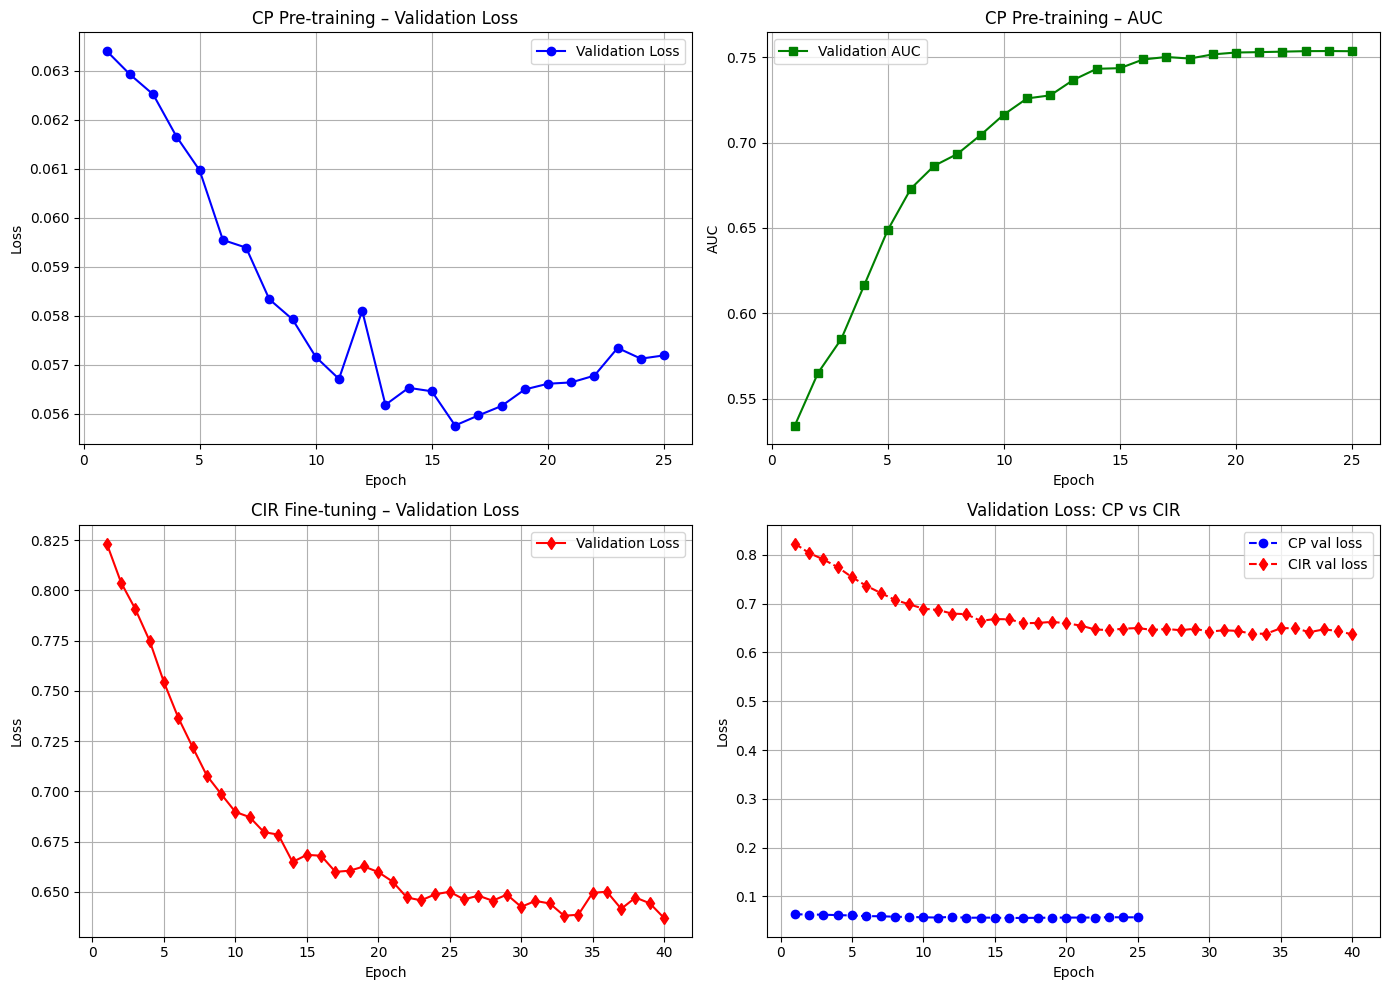

✅ Plots saved to /kaggle/working/checkpoints/learning_curves.png


In [138]:
import matplotlib.pyplot as plt
import torch
from pathlib import Path

output_dir = Path("/kaggle/working/checkpoints")

# --- Collect CP metrics ---
cp_epochs = []
cp_val_loss = []
cp_auc = []

for cp_file in sorted(output_dir.glob("cp_epoch*.pt")):
    ckpt = torch.load(cp_file, map_location="cpu")
    epoch = ckpt["epoch"]
    metrics = ckpt["metrics"]
    cp_epochs.append(epoch)
    cp_val_loss.append(metrics["val_loss"])
    cp_auc.append(metrics["auc"])

# --- Collect CIR metrics ---
cir_epochs = []
cir_val_loss = []

for cir_file in sorted(output_dir.glob("cir_epoch*.pt")):
    ckpt = torch.load(cir_file, map_location="cpu")
    epoch = ckpt["epoch"]
    metrics = ckpt["metrics"]
    cir_epochs.append(epoch)
    cir_val_loss.append(metrics["val_loss"])

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CP Loss
ax = axes[0, 0]
ax.plot(cp_epochs, cp_val_loss, 'b-o', label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CP Pre-training – Validation Loss")
ax.grid(True)
ax.legend()

# CP AUC
ax = axes[0, 1]
ax.plot(cp_epochs, cp_auc, 'g-s', label="Validation AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC")
ax.set_title("CP Pre-training – AUC")
ax.grid(True)
ax.legend()

# CIR Loss
ax = axes[1, 0]
ax.plot(cir_epochs, cir_val_loss, 'r-d', label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CIR Fine-tuning – Validation Loss")
ax.grid(True)
ax.legend()

# Combined (optional) – show both losses on same plot
ax = axes[1, 1]
ax.plot(cp_epochs, cp_val_loss, 'b--o', label="CP val loss")
ax.plot(cir_epochs, cir_val_loss, 'r--d', label="CIR val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Validation Loss: CP vs CIR")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "learning_curves.png", dpi=150)
plt.show()

print("✅ Plots saved to", output_dir / "learning_curves.png")

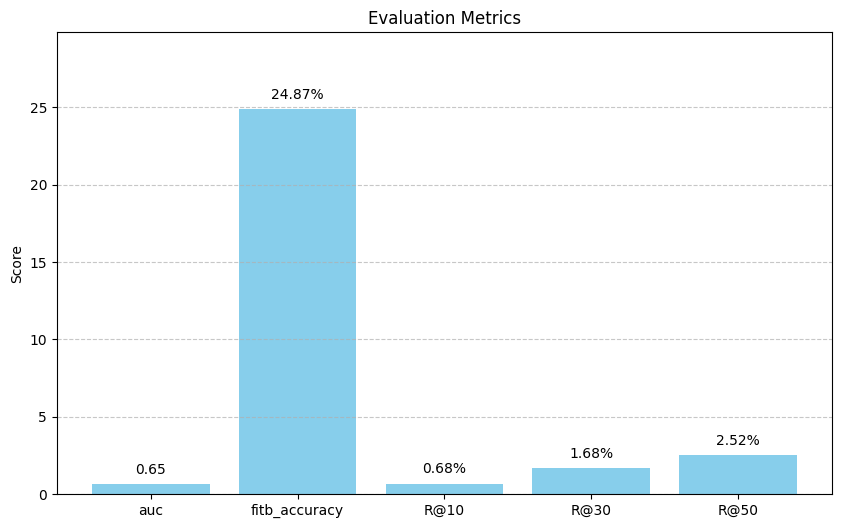

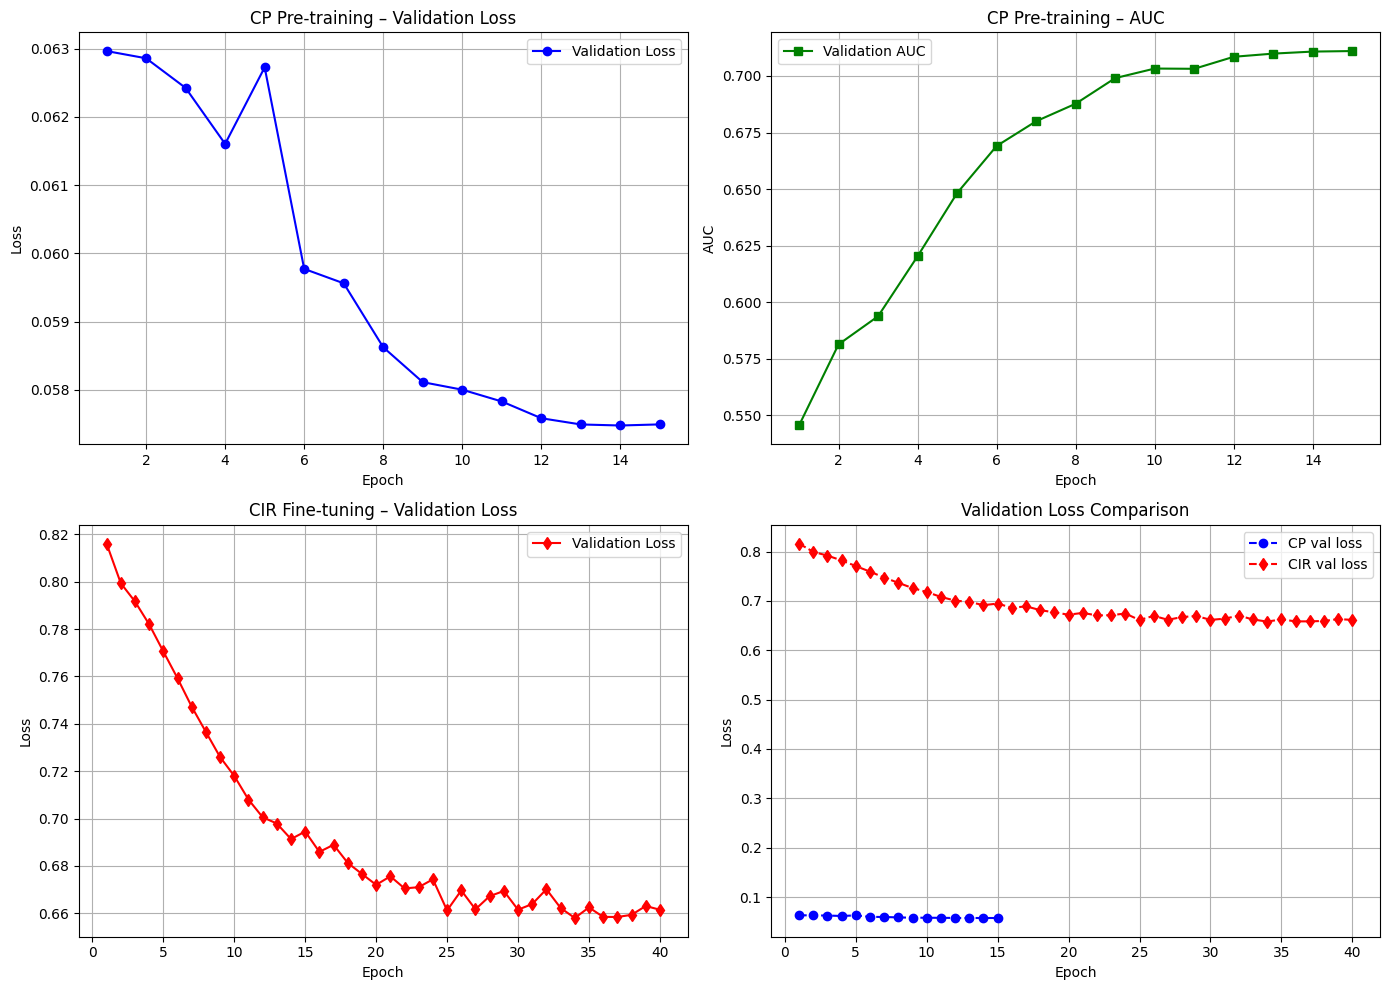

✅ Plots saved to /kaggle/working/checkpoints/learning_curves.png


In [ ]:
import matplotlib.pyplot as plt
import torch
import json
from pathlib import Path

output_dir = Path("/kaggle/working/checkpoints")

# ---------- Load evaluation results for bar chart ----------
with open(output_dir / "eval_results.json", "r") as f:
    eval_results = json.load(f)

names = []
values = []
for k, v in eval_results.items():
    if "R@" in k:
        names.append(k)
        values.append(v * 100)          # percentage
    else:
        # AUC is already a fraction, others (fitb_accuracy) are fractions too
        names.append(k)
        values.append(v * 100 if "auc" not in k else v)

# Bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(names, values, color='skyblue')
plt.ylabel("Score")
plt.title("Evaluation Metrics")
for idx, (bar, val) in enumerate(zip(bars, values)):
    name = names[idx]
    suffix = "%" if any(x in name for x in ["R@", "fitb"]) else ""
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.2f}{suffix}", ha='center', va='bottom')
plt.ylim(0, max(values) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ---------- Learning curves (validation only) ----------
cp_epochs, cp_val_loss, cp_auc = [], [], []
for cp_file in sorted(output_dir.glob("cp_epoch*.pt")):
    ckpt = torch.load(cp_file, map_location="cpu")
    cp_epochs.append(ckpt["epoch"])
    cp_val_loss.append(ckpt["metrics"]["val_loss"])
    cp_auc.append(ckpt["metrics"]["auc"])

cir_epochs, cir_val_loss = [], []
for cir_file in sorted(output_dir.glob("cir_epoch*.pt")):
    ckpt = torch.load(cir_file, map_location="cpu")
    cir_epochs.append(ckpt["epoch"])
    cir_val_loss.append(ckpt["metrics"]["val_loss"])

# Create 2x2 grid: CP loss, CP AUC, CIR loss, combined
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CP Loss
ax = axes[0, 0]
ax.plot(cp_epochs, cp_val_loss, 'b-o', label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CP Pre‑training – Validation Loss")
ax.grid(True); ax.legend()

# CP AUC
ax = axes[0, 1]
ax.plot(cp_epochs, cp_auc, 'g-s', label="Validation AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC")
ax.set_title("CP Pre‑training – AUC")
ax.grid(True); ax.legend()

# CIR Loss
ax = axes[1, 0]
ax.plot(cir_epochs, cir_val_loss, 'r-d', label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CIR Fine‑tuning – Validation Loss")
ax.grid(True); ax.legend()

# Combined losses
ax = axes[1, 1]
ax.plot(cp_epochs, cp_val_loss, 'b--o', label="CP val loss")
ax.plot(cir_epochs, cir_val_loss, 'r--d', label="CIR val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Validation Loss Comparison")
ax.grid(True); ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "learning_curves.png", dpi=150)
plt.show()
print("✅ Plots saved to", output_dir / "learning_curves.png")